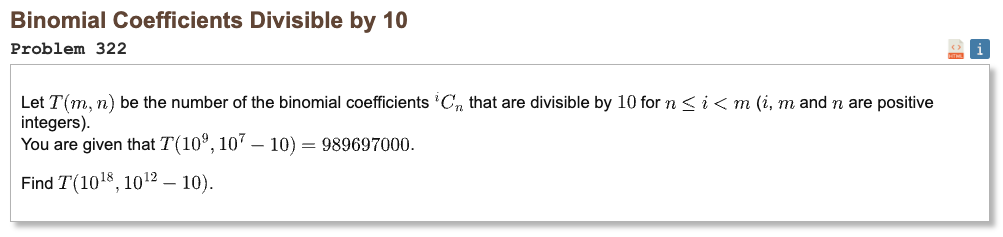

## Initial approach

* count the opposite cases first
* use Kummer logic to detect when a binomial coefficient avoids a prime factor
* avoiding factor 2 means no carry in base 2
* avoiding factor 5 means no carry in base 5
* the overlap must be counted with both base conditions together
* base 10 carry is not enough for the overlap
* use Chinese remainder logic to count the shared valid cases efficiently

In [1]:
from functools import lru_cache

def base_length(n, base):
    length = 1

    while n >= base:
        n //= base
        length += 1

    return length

def digits_msd(n, base, length):
    digits = [0] * length

    for i in range(length - 1, -1, -1):
        digits[i] = n % base
        n //= base

    return digits

def digits_lsd(n, base, length):
    digits = []

    for _ in range(length):
        digits.append(n % base)
        n //= base

    return digits

def count_no_carry(n, limit, base):
    if limit <= 0:
        return 0

    length = max(base_length(n, base), base_length(limit - 1, base))
    n_digits = digits_msd(n, base, length)
    limit_digits = digits_msd(limit - 1, base, length)

    @lru_cache(None)
    def dp(pos, tight):
        if pos == length:
            return 1

        max_digit = limit_digits[pos] if tight else base - 1
        allowed_digit = base - 1 - n_digits[pos]
        upper = min(max_digit, allowed_digit)

        total = 0

        for digit in range(upper + 1):
            total += dp(pos + 1, tight and digit == max_digit)

        return total

    return dp(0, True)

def generate_allowed_residues(n, base):
    length = base_length(n, base)
    n_digits = digits_lsd(n, base, length)

    values = [0]
    place = 1

    for digit in n_digits:
        new_values = []

        for value in values:
            for add_digit in range(base - digit):
                new_values.append(value + add_digit * place)

        values = new_values
        place *= base

    values.sort()
    return values, place

def lower_bound(arr, x):
    lo = 0
    hi = len(arr)

    while lo < hi:
        mid = (lo + hi) // 2

        if arr[mid] < x:
            lo = mid + 1
        else:
            hi = mid

    return lo

def upper_bound(arr, x):
    lo = 0
    hi = len(arr)

    while lo < hi:
        mid = (lo + hi) // 2

        if arr[mid] <= x:
            lo = mid + 1
        else:
            hi = mid

    return lo

def count_range(arr, lo, hi):
    if lo > hi:
        return 0

    return upper_bound(arr, hi) - lower_bound(arr, lo)

def count_overlap(n, limit):
    residues_2, mod_2 = generate_allowed_residues(n, 2)
    residues_5, mod_5 = generate_allowed_residues(n, 5)

    inverse = pow(mod_2, -1, mod_5)
    transformed_5 = sorted((r * inverse) % mod_5 for r in residues_5)

    total = 0

    for r2 in residues_2:
        if r2 >= limit:
            continue

        max_t = (limit - 1 - r2) // mod_2
        shift = (r2 * inverse) % mod_5

        if shift + max_t < mod_5:
            total += count_range(transformed_5, shift, shift + max_t)
        else:
            total += count_range(transformed_5, shift, mod_5 - 1)
            total += count_range(transformed_5, 0, shift + max_t - mod_5)

    return total

def T(m, n):
    total = m - n

    no2 = count_no_carry(n, total, 2)
    no5 = count_no_carry(n, total, 5)
    both = count_overlap(n, total)

    return total - no2 - no5 + both

assert T(10 ** 9, 10 ** 7 - 10) == 989697000

In [2]:
result = T(10 ** 18, 10 ** 12 - 10)
print("Result:", result)

Result: 999998760323313995
